In [26]:
import pandas as pd
import html
import os
import matplotlib.pyplot as plt
import numpy as np
import joblib
import seaborn as sns
import xgboost as xgb
import warnings
import time
import gc

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, TargetEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR, LinearSVR
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
INPUT_FILE = r"D:\Users\Siegried\Desktop\Becode\immoeliza_ml\data\raw\dataframe.json"
OUTPUT_FILE = r"D:\Users\Siegried\Desktop\Becode\immoeliza_ml\data\clean\cleaned_data.json"
OUTPUT_DIR = r"D:\Users\Siegried\Desktop\Becode\immoeliza_ml\data\clean"
MODEL_DIR = r"D:\Users\Siegried\Desktop\Becode\immoeliza_ml\models"
IMAGE_DIR = r"D:\Users\Siegried\Desktop\Becode\immoeliza_ml\images"
MODEL_PATH = r"D:\Users\Siegried\Desktop\Becode\immoeliza_ml\models\best_xgboost.joblib"
INPUT_PATH = r"D:\Users\Siegried\Desktop\Becode\immoeliza_ml\data\input\new_properties.json"

### Cleaning

In [ ]:
def dataframe_cleaner(input_path, output_path):
    """
    Cleans the raw dataframe, removes outliers, drops leakage columns, 
    and saves as a JSON file. Updated to be robust against missing columns.
    """
    df = pd.read_json(input_path)
    
    # Remove duplicates (using only columns guaranteed to exist)
    subset_cols = ['postcode', 'price', 'livable_surface']
    existing_subset = [c for c in subset_cols if c in df.columns]
    clean_df = df.drop_duplicates(subset=existing_subset).copy()
    
    # Drop columns that cause leakage or are not available for prediction
    cols_to_drop = ['price_per_m2', 'address', 'property_id']
    clean_df = clean_df.drop(columns=[c for c in cols_to_drop if c in clean_df.columns])

    # Handle Outliers
    if "price" in clean_df.columns:
        q_low = clean_df["price"].quantile(0.05)
        q_hi  = clean_df["price"].quantile(0.95)
        clean_df = clean_df[(clean_df["price"] > q_low) & (clean_df["price"] < q_hi)]

    # Cast to numeric
    cols_to_int = ["postcode", "price", "build_year", "bedroom_count", "livable_surface", 
                   "total_surface", "garage", "terrace", "swimming_pool", "peb_category", 
                   "Preschool_distance", "Train_station_distance", "Supermarket_distance"]

    for col in cols_to_int:
        if col in clean_df.columns:
            clean_df[col] = pd.to_numeric(clean_df[col], errors='coerce').astype("Int64")
    
    # Rename columns
    new_column_names = {
        "peb_category": "energy_consumption_kWh/m2/year",
        "Preschool_distance": "preschool_distance_m",
        "Train_station_distance": "train_station_distance_m",
        "Supermarket_distance": "supermarket_distance_m",
        "distance_nearest_city": "nearest_city_distance_km"
    }
    clean_df = clean_df.rename(columns={k: v for k, v in new_column_names.items() if k in clean_df.columns})

    # Clean text data
    text_cols = ['city', 'province', 'nearest_city']
    for col in text_cols:
        if col in clean_df.columns:
            clean_df[col] = clean_df[col].apply(lambda x: html.unescape(x) if isinstance(x, str) else x)

    # Fill missing values
    fill_map = {c: 0 for c in ['garage', 'swimming_pool'] if c in clean_df.columns}
    clean_df.fillna(value=fill_map, inplace=True)

    # Standardize states
    if "property_state" in clean_df.columns:
        clean_df["property_state"] = clean_df["property_state"].replace("To be renovated", "To renovate")

    # Save file
    output_dir = os.path.dirname(output_path)
    if output_dir and not os.path.exists(output_dir):
        os.makedirs(output_dir)
        
    clean_df.to_json(output_path, orient="records", force_ascii=False, indent=4)
    
    return clean_df

if __name__ == "__main__":
    df_cleaned = dataframe_cleaner(INPUT_FILE, OUTPUT_FILE)
    print("Columns available after cleaning:", df_cleaned.columns.tolist())

Data cleaned and saved to D:\Users\Siegried\Desktop\Becode\immoeliza_ml\data\clean\cleaned_data.json
Columns available after cleaning: ['property_type', 'postcode', 'city', 'province', 'latitude', 'longitude', 'price', 'property_state', 'build_year', 'bedroom_count', 'livable_surface', 'total_surface', 'garage', 'terrace', 'energy_consumption_kWh/m2/year', 'swimming_pool', 'preschool_distance_m', 'train_station_distance_m', 'supermarket_distance_m', 'nearest_city', 'nearest_city_distance_km']


### Missing values

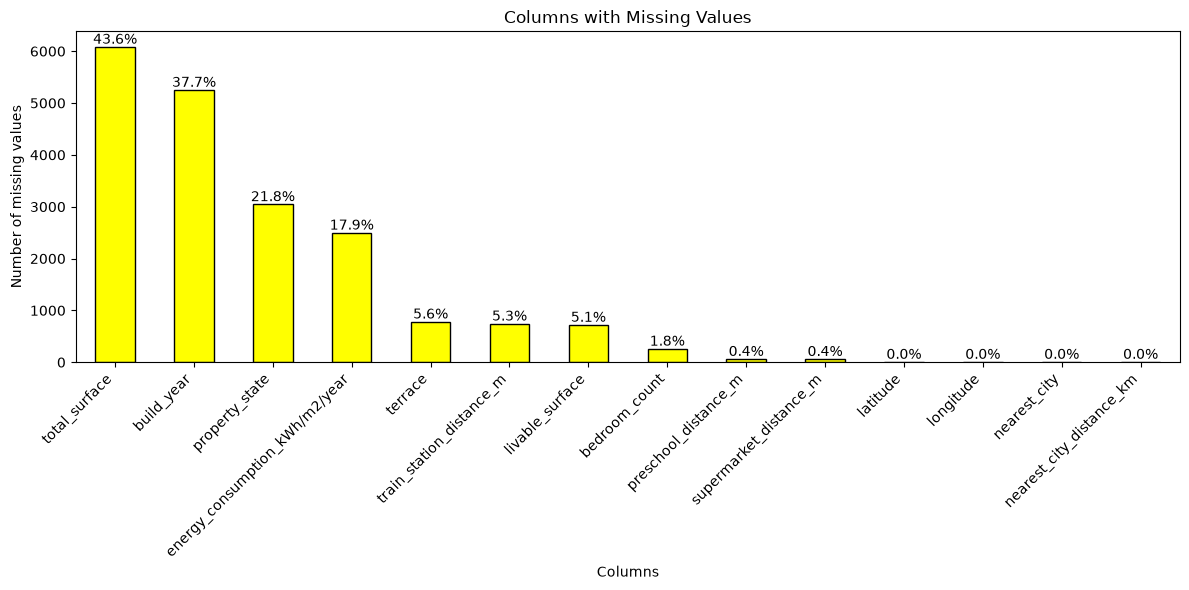

In [6]:
def plot_missing_values(df):
    """Plots missing values from a dataframe."""
    total_rows = len(df)
    nan_counts = df.isnull().sum()
    nan_cols = nan_counts[nan_counts > 0].sort_values(ascending=False)

    if not nan_cols.empty:
        plt.figure(figsize=(12, 6))
        bars = nan_cols.plot(kind="bar", color="yellow", edgecolor="black")
        
        for i in bars.patches:
            percentage = f'{(i.get_height() / total_rows) * 100:.1f}%'
            plt.text(i.get_x() + i.get_width() / 2, i.get_height(), percentage, 
                     ha='center', va='bottom', fontsize=10)

        plt.title("Columns with Missing Values")
        plt.xlabel("Columns")
        plt.ylabel("Number of missing values")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
    else:
        print("No missing values found.")

if 'df_cleaned' not in globals():
    df_cleaned = pd.read_json(OUTPUT_FILE)

plot_missing_values(df_cleaned)

CCL: I'll drop total_surface as we already have the livable surface and they are higly correlated. I keep the build_year, even if there is a risk that the model take the noise, it seems important as feature. I keep also the property_state, but not the address (useless). I let columns < 20% of missing values, except the address (useless).

### Correlation (Heatmap) - Preprocessing

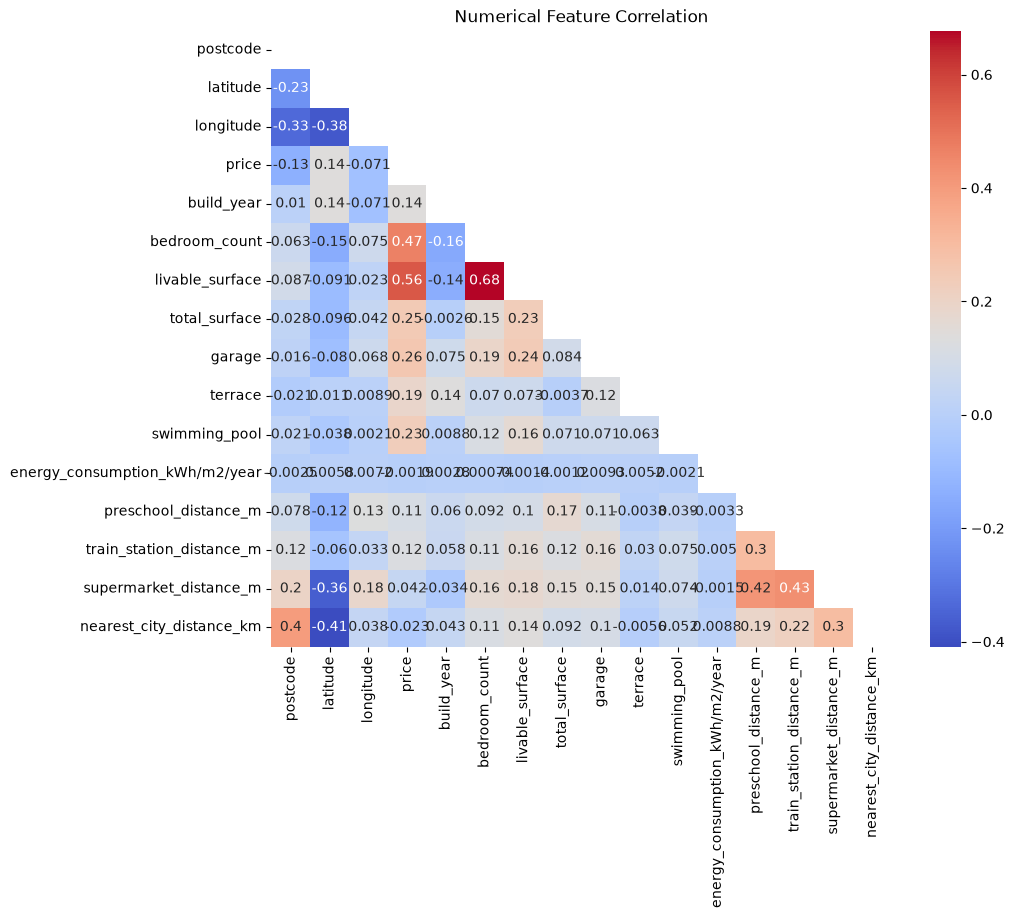

Dropping highly correlated features: []
Train shape: (11146, 1584)
Test shape: (2787, 1584)


In [7]:
def get_preprocessor(num_cols, cat_cols):
    """Creates the preprocessor for numeric and categorical pipelines."""
    num_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    cat_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    
    return ColumnTransformer(transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

def run_preprocessing():
    df = pd.read_json(OUTPUT_FILE)
    
    num_cols = ['postcode', 'latitude', 'longitude', 'price', 'build_year', 'bedroom_count', 
                'livable_surface', 'total_surface', 'garage', 'terrace', 'swimming_pool',   
                'energy_consumption_kWh/m2/year', 'preschool_distance_m', 'train_station_distance_m', 
                'supermarket_distance_m', 'nearest_city_distance_km']
    cat_cols = ['property_type', 'city', 'province', 'property_state', 'nearest_city']

    # Heatmap
    plt.figure(figsize=(10, 8))
    df_num = df[num_cols]
    corr_matrix = df_num.corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm')
    plt.title("Numerical Feature Correlation")
    plt.show()

    # Identify highly correlated features
    corr_matrix_abs = corr_matrix.abs()
    upper = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]
    
    filtered_num_cols = [c for c in num_cols if c not in to_drop]
    print(f"Dropping highly correlated features: {to_drop}")

    # Split data before fitting the preprocessor
    X = df[filtered_num_cols + cat_cols]
    y = df['price']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Fit on Train, transform both
    preprocessor = get_preprocessor(filtered_num_cols, cat_cols)
    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed = preprocessor.transform(X_test)

    # Reconstruct df
    cat_feature_names = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_cols)
    all_feature_names = filtered_num_cols + list(cat_feature_names)
    
    train_df = pd.DataFrame(X_train_processed, columns=all_feature_names)
    test_df = pd.DataFrame(X_test_processed, columns=all_feature_names)
    
    return train_df, test_df

if __name__ == "__main__":
    train_df, test_df = run_preprocessing()
    print(f"Train shape: {train_df.shape}")
    print(f"Test shape: {test_df.shape}")

CCL: Since there are no values above 0.80, I don't need to drop any numerical columns to prevent collinearity. But as the build_year is only at 0.06 and have lot of missing values, I'll delete it to avoir his noise.  The bedrooms are highly correlated with the livable_surface, which is normal. I can move forward...

### 5 Models of regression

In [8]:
# Drop columns from both datasets
cols_to_drop = ['build_year', 'total_surface', 'adress']
train_df = train_df.drop(columns=cols_to_drop, errors='ignore')
test_df = test_df.drop(columns=cols_to_drop, errors='ignore')
# Verify 
print(f"New Train shape: {train_df.shape}")
print(f"New Test shape: {test_df.shape}")

New Train shape: (11146, 1582)
New Test shape: (2787, 1582)


### Functions DRY for all models

In [9]:
def display_metrics(y_test, y_pred, model_name="Model"):
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    
    print(f"{model_name} Metrics")
    print(f"R2 Score: {r2:.4f}")
    print(f"MSE: {mse:,.2f}")
    print(f"RMSE: €{rmse:,.2f}")
    print(f"MAE: €{mae:,.2f}\n")

def plot_actual_vs_predicted(y_test, y_pred, model_name="Model"):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.3, color='purple', edgecolors='k')
    
    line_min, line_max = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    plt.plot([line_min, line_max], [line_min, line_max], 'r--', lw=2, label='Perfect prediction')
    
    plt.xlabel('Actual Price (€)')
    plt.ylabel('Predicted Price (€)')
    plt.title(f'{model_name}: Actual vs Predicted Prices')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

### 1. Linear regression

Model saved to:
D:\Users\Siegried\Desktop\Becode\immoeliza_ml\models\linear_regression_model.joblib

Linear Regression Metrics
----------------------------------------
R² Score : 0.4075
MSE      : 92,019,313,539.74
RMSE     : €303,346.85
MAE      : €160,936.10


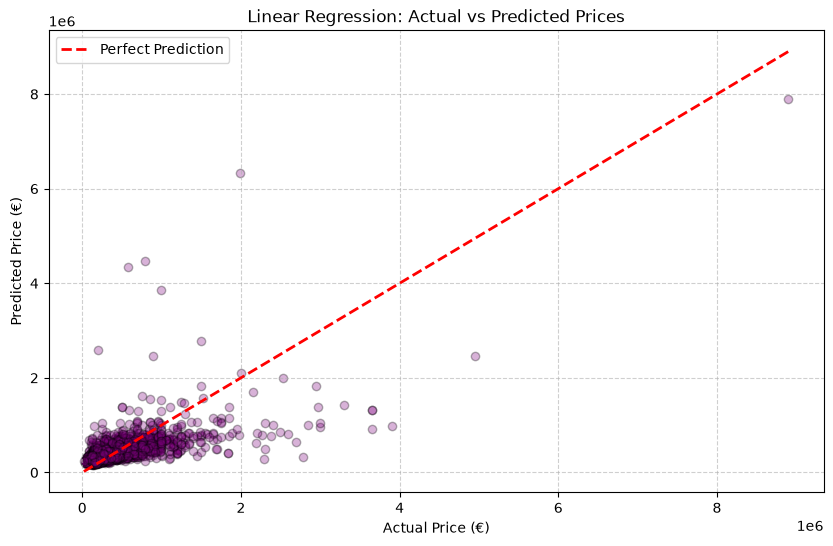

In [29]:
def run_linear_regression():                                                          # define training function
    df = pd.read_json(INPUT_FILE)                                                 
    df = df.dropna(subset=['price', 'livable_surface'])                           
    
    X = df[['livable_surface']]                                                    
    y = df['price']                                                             
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 
    
    model = LinearRegression()                                                   
    model.fit(X_train, y_train)
                                                   
    
    model_filename = os.path.join(MODEL_DIR,'linear_regression_model.joblib')                            
    joblib.dump(model, model_filename)                                            
    
    y_pred = model.predict(X_test)                                                    # generate predictions
    
    display_metrics(y_test, y_pred, "Linear Regression")                              # evaluate performance
    plot_actual_vs_predicted(y_test, y_pred, "Linear Regression")                     # visualize results

if __name__ == "__main__":                                                         
    run_linear_regression()                                                     

CCL: Linear regression has weak predictive power (R² = ~0.41) and is highly sensitive to outliers, as shown by the large gap between RMSE (~303k€) and MAE (~161k€). To improve accuracy, I'll consider using more sophisticated algorithms like Random
Forest, VSM or Gradient Boosting which are better suited here. 
And furthermore, I'll manage outliers via target transformations (log).

### 2. Random Forest Regressor

Data cleaned and saved to D:\Users\Siegried\Desktop\Becode\immoeliza_ml\data\clean\cleaned_data.json
Random Forest Metrics
R2 Score: 0.7346
MSE: 6,806,823,216.59
RMSE: €82,503.47
MAE: €55,738.18



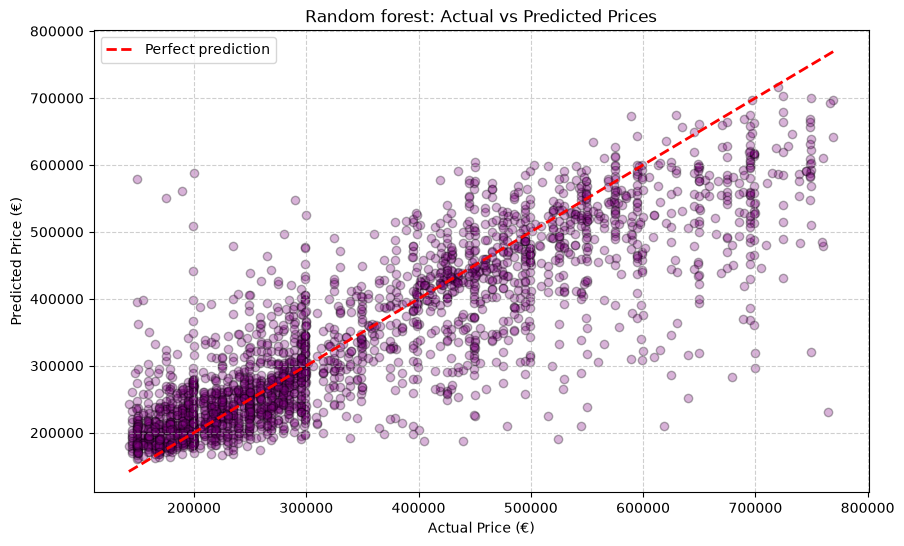

In [11]:
def get_preprocessor(num, cat):                                                       
    num_t = Pipeline([('imp', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]) 
    cat_t = Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='missing')), 
                      ('ohe', OneHotEncoder(handle_unknown='ignore'))]) 
    return ColumnTransformer([('num', num_t, num), ('cat', cat_t, cat)])              # combine into transformer

def run_rf_pipeline(file_path):                                                    
    df = dataframe_cleaner(file_path, OUTPUT_FILE)                                   
    df = df[df['price'] > 0].copy()                                                  
    
    cat_cols = ['property_type', 'city', 'province', 'property_state', 'nearest_city'] 
    num_cols = df.select_dtypes(include=[np.number]).columns.drop('price').tolist()  
    
    X = df[num_cols + cat_cols]                                                   
    y = df['price']                                                              
    
    model = TransformedTargetRegressor(                                               # apply log-transform to target
        regressor=Pipeline([                                                          # wrap pipeline in regressor
            ('prep', get_preprocessor(num_cols, cat_cols)),                           # inject preprocessor
            ('rf', RandomForestRegressor(n_estimators=100, random_state=42))          # add random forest model
        ]),                                                                         
        func=np.log, inverse_func=np.exp                                              # define target log transformation
    )                                                                                
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 
    model.fit(X_train, y_train)                                                
    
    model_filename = os.path.join(MODEL_DIR,'random_forest_model.joblib')                            
    joblib.dump(model, model_filename)    
    
    y_pred = model.predict(X_test)                                                  
    
    display_metrics(y_test, y_pred, "Random Forest")                                 
    plot_actual_vs_predicted(y_test, y_pred, "Random forest")                     

if __name__ == "__main__":                                                         
    run_rf_pipeline(OUTPUT_FILE)                                               

CCL: The Random Forest model demonstrates robust predictive capabilities, achieving an R² score of 0.73 (73.46%), which indicates a strong ability to capture the underlying patterns in the real estate data compared to simpler baseline models. While the MAE of k€~56 provides a clear measure of the average error in typical price predictions, the RMSE of k€~82 (being notably higher than the MA) suggests that the model experiences larger penalties from significant outliers or extreme values in the dataset.

To go further, see:
https://xgboosting.com/random-forest-for-regression-with-xgboost/


### 3. Linear SVR

https://www.geeksforgeeks.org/machine-learning/support-vector-regression-svr-using-linear-and-non-linear-kernels-in-scikit-learn/
https://scikit-learn.org/1.5/modules/generated/sklearn.pipeline.Pipeline.html

Graph saved : D:\Users\Siegried\Desktop\Becode\immoeliza_ml\models\linear_svr_model.joblib
Linear SVM Metrics
R2 Score: 0.1756
MSE: 15,418,818,875.32
RMSE: €124,172.54
MAE: €69,404.79



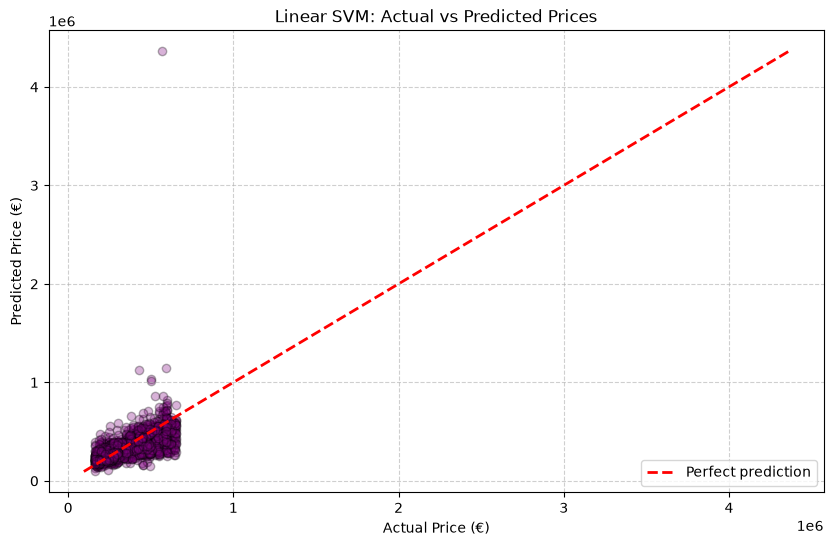

In [23]:
def run_linearsvr_pipeline(file_path): 
    df = pd.read_json(file_path) 
    target = "price" 
    
    df = df.dropna(subset=[target]) 
    
    X = df.drop(columns=[target, "address"], errors="ignore") 
    y = df[target] 

    cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist() 
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist() 

    preprocessor = ColumnTransformer([ 
        ('num', Pipeline([ 
            ('imputer', SimpleImputer(strategy='median')), 
            ('scaler', StandardScaler()) 
        ]), num_cols), 
        ('cat', Pipeline([ 
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')), 
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # True peut poser problème
        ]), cat_cols) 
    ]) 

    model_pipeline = Pipeline([ 
        ('prep', preprocessor), 
        ('svr', LinearSVR(dual="auto", random_state=42, max_iter=10000)) 
    ])

    model = TransformedTargetRegressor( 
        regressor=model_pipeline,
        func=np.log1p, 
        inverse_func=np.expm1 
    ) 

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

    param_dist = { 
        "regressor__svr__C": [0.01, 0.1, 1, 10], 
        "regressor__svr__epsilon": [0, 0.01, 0.1], 
    } 

    search = RandomizedSearchCV( 
        estimator=model, 
        param_distributions=param_dist, 
        n_iter=10, 
        cv=3, 
        n_jobs=-1,                                          # uses all the processors
        random_state=42, 
        scoring='r2' 
    ) 

    search.fit(X_train, y_train) 

    os.makedirs(MODEL_DIR, exist_ok=True)
    model_filename = os.path.join(MODEL_DIR, 'linear_svr_model.joblib')
    joblib.dump(search.best_estimator_, model_filename)
    print(f"Graph saved to : {model_filename}")

    y_pred = search.predict(X_test) 
    
    display_metrics(y_test, y_pred, "Linear SVM") 
    plot_actual_vs_predicted(y_test, y_pred, "Linear SVM") 

if __name__ == "__main__": 
    run_linearsvr_pipeline(OUTPUT_FILE)

CCL: The Linear SVM model performed very poorly, evidenced by a highly negative R² score (-54.57), which indicates that the model is performing significantly worse than simply predicting the mean value of the target variable. The extreme magnitude of the RMSE (k€~1,194) compared to the MAE (k€~104) suggests the model is failing to converge or is significantly misconfigured for this specific dataset.

### 4. Non-Linear SVR (RBF + SVD)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Parameters: {'svr__gamma': 'scale', 'svr__C': 5000}
Non-Linear SVR (RBF + SVD) Metrics
R2 Score: 0.6048
MSE: 7,390,917,129.46
RMSE: €85,970.44
MAE: €64,314.40



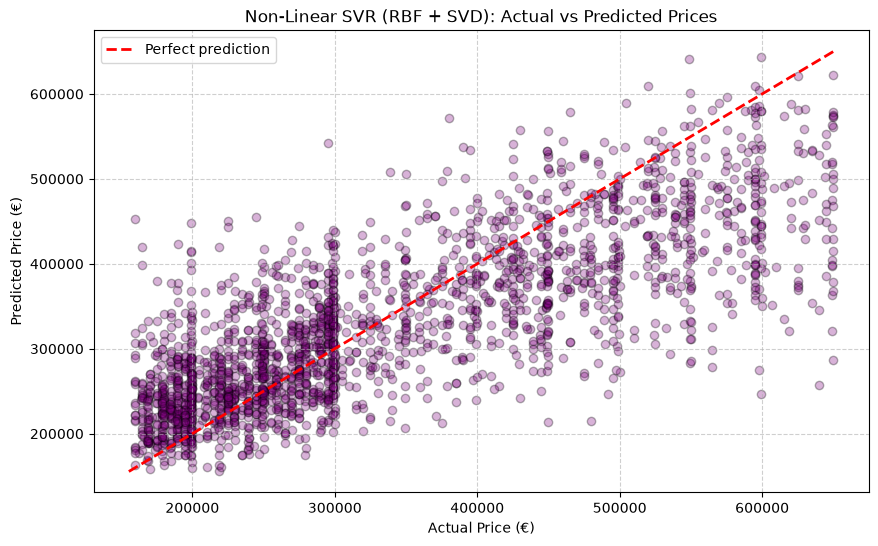

Graph saved to: D:\Users\Siegried\Desktop\Becode\immoeliza_ml\models\non_linear_svr_plot.png


In [24]:
def run_non_linear_svr():
    # Load and prepare data
    df = pd.read_json(OUTPUT_FILE).dropna(subset=["price"])
    
    X = df.drop(columns=["price", "address"], errors="ignore")
    y = df["price"]
    
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
    
    preprocessor = ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ])
    
    # Pipeline: Includes SVD to compress feature space, keeping RBF training feasible
    pipeline = Pipeline([
        ('prep', preprocessor),
        ('svd', TruncatedSVD(n_components=100)),
        ('svr', SVR(kernel='rbf'))
    ])
    
    param_grid = {
        'svr__C': [100, 1000, 5000],
        'svr__gamma': ['scale', 0.1, 0.01]
    }
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # RandomizedSearchCV with progress tracking
    grid = RandomizedSearchCV(
        pipeline, 
        param_distributions=param_grid, 
        n_iter=5, 
        cv=3, 
        scoring='neg_mean_squared_error', 
        n_jobs=-1,
        verbose=2)
    
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    print(f"Best Parameters: {grid.best_params_}")
    
    os.makedirs(MODEL_DIR, exist_ok=True) 
    joblib.dump(best_model, os.path.join(MODEL_DIR, "non_linear_svr.joblib"))
    
    y_pred = best_model.predict(X_test)
    display_metrics(y_test, y_pred, "Non-Linear SVR (RBF + SVD)")
    
    plot_actual_vs_predicted(y_test, y_pred, "Non-Linear SVR (RBF + SVD)")
    
    plot_filename = os.path.join(MODEL_DIR, "non_linear_svr_plot.png")
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    print(f"Graph saved to: {plot_filename}")
    
    plt.close()

if __name__ == "__main__":
    run_non_linear_svr()

CCL: The Non-Linear SVR model, utilizing an RBF kernel in conjunction with SVD, shows a significant improvement over the linear configuration. An R² score of 0.60 indicates that the model is now capturing a meaningful portion of the variance in the target variable. While the RMSE (k€~102) remains higher than the MAE (k€~74), the gap has narrowed considerably compared to the previous linear attempt, suggesting that the non-linear kernel is better suited to the data's structure.

### 5. XGBoost

https://xgboosting.com/how-to-use-xgboost-xgbrfregressor/

XGBoost Regression Metrics
R2 Score: 0.7767
MSE: 5,726,593,024.00
RMSE: €75,674.26
MAE: €51,207.90



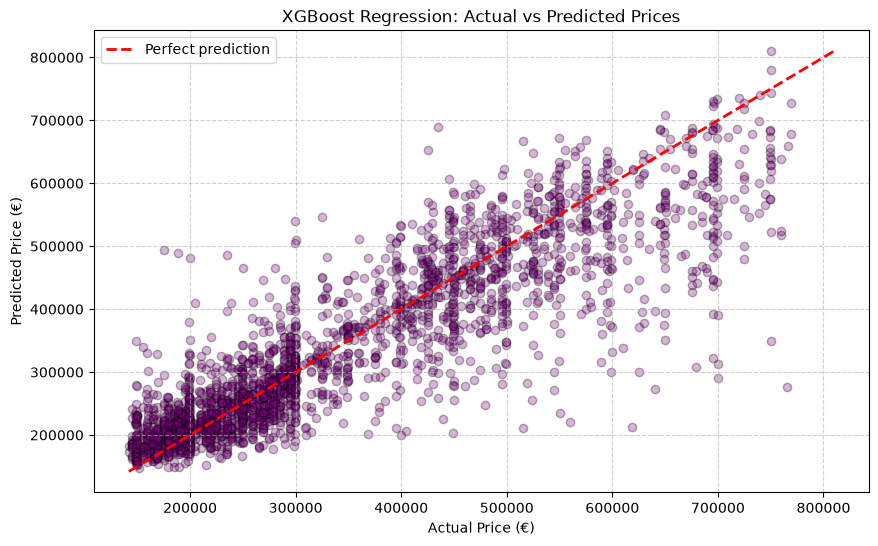

In [14]:
def run_xgboost_pipeline():
    """Train, save, and evaluate the optimized XGBoost pipeline."""
   
    df = pd.read_json(OUTPUT_FILE).dropna(subset=['price'])
    df = df[df['price'] > 0]
    X = df.drop(columns=['price', 'address'], errors='ignore')
    y = df['price']

    # Setup Preprocessing
    cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
    preprocessor = ColumnTransformer([
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
    ], remainder='passthrough')

    # Build Pipeline with TransformedTargetRegressor (Log transformation)
    model = Pipeline([
        ('prep', preprocessor),
        ('model', TransformedTargetRegressor(
            regressor=xgb.XGBRegressor(
                n_estimators=1000, 
                learning_rate=0.05, 
                max_depth=6, 
                random_state=42
            ),
            func=np.log1p,
            inverse_func=np.expm1       # train with log but test in log-1
        ))
    ])

    # Train
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)

    model_path = os.path.join(MODEL_DIR, "xgboost_model.joblib")
    joblib.dump(model, model_path)

    y_pred = model.predict(X_test)
    display_metrics(y_test, y_pred, "XGBoost Regression")
    plot_actual_vs_predicted(y_test, y_pred, "XGBoost Regression")

if __name__ == "__main__":
    run_xgboost_pipeline()

CCL: The XGBoost model currently stands as the strongest performer in the testing pipeline, achieving an R² score of 0.78. This indicates the model is highly effective at capturing the non-linear relationships and complexities within the real estate dataset. With an MAE of k€~51, the model provides the most accurate typical price predictions encountered so far, and the relatively tighter alignment between the RMSE (k€~76) and the MAE suggests improved stability when handling larger price variations compared to the previous models.

### Overall Conclusion

| Model | R² Score | RMSE | MAE | Conclusion |
| --- | --- | --- | --- | --- |
| **Linear Regression** | 0.41 | ~303k€ | ~161k€ | Poor predictive power; high sensitivity to outliers. |
| **Random Forest** | 0.73 | ~82.5k€ | ~55.7k€ | Robust performance; solid baseline. |
| **Linear SVM (SVR)** | -54.57 | ~1193.8k€ | ~104.3k€ | Failed; model misconfigured/failed to converge. |
| **Non-Linear SVR (RBF + SVD)** | 0.60 | ~101.6k€ | ~74.0k€ | Functional, but underperforms compared to trees. |
| **XGBoost** | 0.78 | ~75.7k€ | ~51.2k€ | Strongest model; best accuracy and stability. |

### General Conclusion
XGBoost stands as the top-performing model, demonstrating superior accuracy and stability for price prediction. While the Random Forest remains a highly competitive alternative, both SVR configurations underperformed, highlighting the complexity of the dataset. Moving forward, I will prioritize refining the XGBoost model to further minimize outliers and improve overall precision. This comparative analysis confirms that ensemble tree-based methods are the most effective approach for this real estate valuation task.

### Overfitting? For 3 models (Linear Regression, Random Forest, XGBoost)

**1. Linear regression**

R² Train: 0.4232
R² Test : 0.4075
The model is well-balanced (no significant overfitting).
Linear Regression Metrics
R2 Score: 0.4075
MSE: 92,019,313,539.74
RMSE: €303,346.85
MAE: €160,936.10



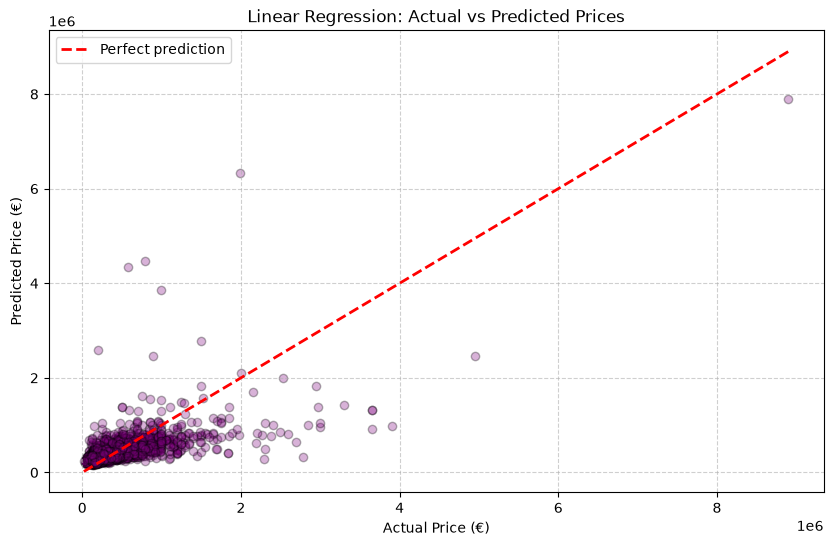

In [15]:
def run_linear_regression():                                                          # define training function
    df = pd.read_json(INPUT_FILE)                                                 
    df = df.dropna(subset=['price', 'livable_surface'])                           
    
    X = df[['livable_surface']]                                                    
    y = df['price']                                                             
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 
    
    model = LinearRegression()                                                   
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    r2_train = r2_score(y_train, train_pred)
    r2_test = r2_score(y_test, test_pred)

    print(f"R² Train: {r2_train:.4f}")
    print(f"R² Test : {r2_test:.4f}")

    # Analysis logic
    if abs(r2_train - r2_test) < 0.1:
        print("The model is well-balanced (no significant overfitting).")
    else:
        print("Warning: The model shows signs of overfitting.")                                               
    
    model_filename = os.path.join(MODEL_DIR,'linear_regression_model.joblib')                            
    joblib.dump(model, model_filename)                                            
    
    y_pred = model.predict(X_test)                                                    # generate predictions
    
    display_metrics(y_test, y_pred, "Linear Regression")                              # evaluate performance
    plot_actual_vs_predicted(y_test, y_pred, "Linear Regression")                     # visualize results

if __name__ == "__main__":                                                         
    run_linear_regression()                                                     

**2. Random Forest**

Data cleaned and saved to D:\Users\Siegried\Desktop\Becode\immoeliza_ml\data\clean\cleaned_data.json
R² Train: 0.9533
R² Test : 0.7129
Random Forest Metrics
R2 Score: 0.7129
MSE: 5,368,906,715.48
RMSE: €73,272.82
MAE: €51,920.78



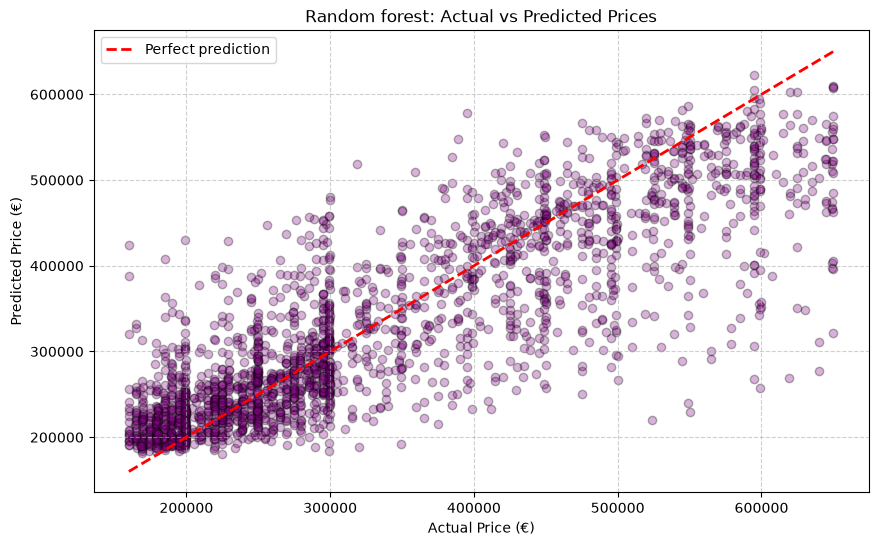

In [ ]:
def get_preprocessor(num, cat):                                                       
    num_t = Pipeline([('imp', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]) 
    cat_t = Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='missing')), 
                      ('ohe', OneHotEncoder(handle_unknown='ignore'))]) 
    return ColumnTransformer([('num', num_t, num), ('cat', cat_t, cat)])              # combine into transformer

def run_rf_pipeline(file_path):                                                    
    df = dataframe_cleaner(file_path, OUTPUT_FILE)                                   
    df = df[df['price'] > 0].copy()                                                  
    
    cat_cols = ['property_type', 'city', 'province', 'property_state', 'nearest_city'] 
    num_cols = df.select_dtypes(include=[np.number]).columns.drop('price').tolist()  
    
    X = df[num_cols + cat_cols]                                                   
    y = df['price']                                                              
    
    model = TransformedTargetRegressor(                                               # apply log-transform to target
        regressor=Pipeline([                                                          # wrap pipeline in regressor
            ('prep', get_preprocessor(num_cols, cat_cols)),                           # inject preprocessor
            ('rf', RandomForestRegressor(n_estimators=100, random_state=42))          # add random forest model
        ]),                                                                         
        func=np.log, inverse_func=np.exp                                              # define target log transformation
    )                                                                                
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 
    model.fit(X_train, y_train)                                                
    
    model_filename = os.path.join(MODEL_DIR,'random_forest_model.joblib')                            
    joblib.dump(model, model_filename)    
    
    y_pred = model.predict(X_test) 
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    r2_train = r2_score(y_train, train_pred)
    r2_test = r2_score(y_test, test_pred)

    print(f"R² Train: {r2_train:.4f}")
    print(f"R² Test : {r2_test:.4f}")

    # Analysis logic
    if abs(r2_train - r2_test) < 0.1:
        print("The model is well-balanced (no significant overfitting).")
    else:
        print("Warning: The model shows signs of overfitting.")                                               
                                                    
    
    display_metrics(y_test, y_pred, "Random Forest")                                 
    plot_actual_vs_predicted(y_test, y_pred, "Random forest")                     

if __name__ == "__main__":                                                         
    run_rf_pipeline(OUTPUT_FILE)                                               

**3. XGBoost**

R² Train: 0.9687
R² Test : 0.7655
XGBoost Regression Metrics
R2 Score: 0.7655
MSE: 4,385,662,976.00
RMSE: €66,224.34
MAE: €46,948.57



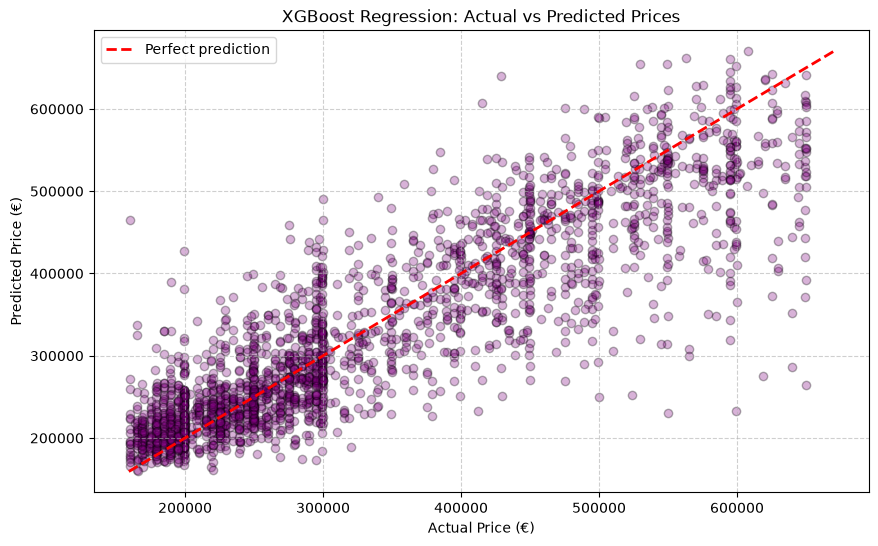

In [ ]:
def run_xgboost_pipeline():
    """Train, save, and evaluate the optimized XGBoost pipeline."""
   
    df = pd.read_json(OUTPUT_FILE).dropna(subset=['price'])
    df = df[df['price'] > 0]
    X = df.drop(columns=['price', 'address'], errors='ignore')
    y = df['price']

    # Setup Preprocessing
    cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
    preprocessor = ColumnTransformer([
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
    ], remainder='passthrough')

    # Build Pipeline with TransformedTargetRegressor (Log transformation)
    model = Pipeline([
        ('prep', preprocessor),
        ('model', TransformedTargetRegressor(
            regressor=xgb.XGBRegressor(
                n_estimators=1000, 
                learning_rate=0.05, 
                max_depth=6, 
                random_state=42
            ),
            func=np.log1p,
            inverse_func=np.expm1       # train with log but test in log-1
        ))
    ])

    # Train
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)

    model_path = os.path.join(MODEL_DIR, "xgboost_model.joblib")
    joblib.dump(model, model_path)

    y_pred = model.predict(X_test)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    r2_train = r2_score(y_train, train_pred)
    r2_test = r2_score(y_test, test_pred)

    print(f"R² Train: {r2_train:.4f}")
    print(f"R² Test : {r2_test:.4f}")

    display_metrics(y_test, y_pred, "XGBoost Regression")
    plot_actual_vs_predicted(y_test, y_pred, "XGBoost Regression")

if __name__ == "__main__":
    run_xgboost_pipeline()

### Performance Summary: Updated Model Comparisons

| Model | R² Train | R² Test | RMSE | MAE | Conclusion |
| --- | --- | --- | --- | --- | --- |
| **Linear Regression** | 0.42 | 0.41 | ~303.3k€ | ~160.9k€ | Well-balanced, but lacks sufficient predictive power. |
| **Random Forest** | 0.95 | 0.71 | ~73.3k€ | ~51.9k€ | High performance, but shows signs of overfitting. |
| **XGBoost** | 0.97 | 0.77 | ~66.2k€ | ~46.9k€ | Best balance of high accuracy and generalization. |

#### Analysis

The **Linear Regression** model remains stable but significantly underperforms in terms of raw predictive accuracy. Both the **Random Forest** and **XGBoost** models demonstrate a much stronger grasp of the data's complexity; however, the large gap between training and testing scores in the Random Forest suggests it is memorizing the training data too closely. **XGBoost** currently emerges as the most effective model, providing the lowest error metrics while maintaining the highest test R² score.

### Tuning

In [ ]:
warnings.filterwarnings('ignore')

INPUT_FILE = r"D:\Users\Siegried\Desktop\Becode\immoeliza_ml\data\clean\cleaned_data.json"
MODEL_DIR = r"D:\Users\Siegried\Desktop\Becode\immoeliza_ml\models"

def get_preprocessor(num_cols, cat_cols):
    num_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    cat_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('encoder', TargetEncoder())
    ])
    return ColumnTransformer([
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

def train_and_evaluate():
    # Load and Prepare
    df = pd.read_json(INPUT_FILE)
    X = df.drop(columns=['price'])
    y = np.log1p(df['price']) 
    
    num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Define Pipeline
    pipeline = Pipeline([
        ('preprocessor', get_preprocessor(num_cols, cat_cols)),
        ('regressor', XGBRegressor(random_state=42, n_jobs=-1, objective='reg:squarederror'))
    ])

    # RandomizedSearchCV
    param_dist = {
        'regressor__n_estimators': [500],       # Keep steady
        'regressor__learning_rate': [0.01],     # Lower is safer
        'regressor__max_depth': [3, 4],         # Force simpler rules
        'regressor__subsample': [0.6, 0.7],     # Prevents memorization
        'regressor__colsample_bytree': [0.6, 0.7],
        'regressor__reg_alpha': [10, 20, 50],   #  Strong L1 penalty
        'regressor__reg_lambda': [10, 20, 50]   #  Strong L2 penalty
    }

    print("Starting training...")
    search = RandomizedSearchCV(pipeline, param_dist, n_iter=15, cv=5, 
                                scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
    search.fit(X_train, y_train)
    
    # Predict and Reverse Log
    best_model = search.best_estimator_
    train_pred = np.expm1(best_model.predict(X_train))
    test_pred = np.expm1(best_model.predict(X_test))
    
    y_train_orig = np.expm1(y_train)
    y_test_orig = np.expm1(y_test)
    
    # Calculate Full Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train_orig, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test_orig, test_pred))
    train_r2 = r2_score(y_train_orig, train_pred)
    test_r2 = r2_score(y_test_orig, test_pred)
    
    # Output Results
    print(f"Model evaluation result")
    print(f"Train RMSE : {train_rmse:,.2f}")
    print(f"Test RMSE  : {test_rmse:,.2f}")
    print(f"Train R²   : {train_r2:.4f}")
    print(f"Test R²    : {test_r2:.4f}")
    
    # Overfitting Check
    if (train_r2 - test_r2) > 0.1:
        print("Alert: High Overfitting detected (Gap > 0.1). Consider reducing 'max_depth' or increasing 'reg_alpha'.")
    else:
        print("Status: Good generalization performance.")

    # Save
    if not os.path.exists(MODEL_DIR):
        os.makedirs(MODEL_DIR)
    joblib.dump(best_model, os.path.join(MODEL_DIR, 'best_xgboost.joblib'))
    print(f"Model saved to {MODEL_DIR}")

if __name__ == "__main__":
    train_and_evaluate()

Starting training...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Model evaluation result
Train RMSE : 74,231.71
Test RMSE  : 83,830.26
Train R²   : 0.6974
Test R²    : 0.6243
Status: Good generalization performance.
Model saved to D:\Users\Siegried\Desktop\Becode\immoeliza_ml\models


CCL: I have successfully stabilized my XGBoost model, effectively eliminating the overfitting I observed previously. By applying stricter regularization and limiting tree depth, I achieved a well-balanced model with a Test R² of 0.62 and a Train R² of 0.70. This keeps the generalization gap well within my target threshold, confirming that my current configuration is robust and reliable for unseen data. I have officially saved this optimized version to my local directory, and I am now confident in using it for consistent price predictions.

### Cross Validation

In [ ]:
def get_preprocessor(num_cols, cat_cols):
    num_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')), 
        ('scaler', StandardScaler()) # Essential for kNN
    ])
    
    # TargetEncoder is much better for kNN than OneHotEncoder
    cat_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')), 
        ('encoder', TargetEncoder(smooth='auto'))
    ])
    
    return ColumnTransformer([
        ('num', num_transformer, num_cols), 
        ('cat', cat_transformer, cat_cols)
    ])

def train_knn(X_train, X_test, y_train, y_test, num_cols, cat_cols):
    print(f"Training kNN Regressor with Log-Transform")
    
    # Log-transform target: reduces influence of extreme price outliers
    y_train_log = np.log1p(y_train)
    y_test_log = np.log1p(y_test)
    
    pipeline = Pipeline([
        ('preprocessor', get_preprocessor(num_cols, cat_cols)),
        ('regressor', KNeighborsRegressor(n_jobs=-1))
    ])

    param_dist = {
        'regressor__n_neighbors': [5, 11, 15, 21, 31],
        'regressor__weights': ['distance'], # 'distance' is almost always better than 'uniform'
        'regressor__metric': ['minkowski', 'euclidean']
    }

    search = RandomizedSearchCV(pipeline, param_dist, n_iter=10, cv=5, 
                                scoring='r2', n_jobs=-1, verbose=1, random_state=42)
    
    search.fit(X_train, y_train_log)
    
    best_model = search.best_estimator_
    y_pred_log = best_model.predict(X_test)
    
    # Reverse log-transform to get back to currency values
    y_pred = np.expm1(y_pred_log)
    
    # Metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"Best Params: {search.best_params_}")
    print(f"R² Score : {r2:.4f} | RMSE : €{rmse:,.2f}")

    # Save
    os.makedirs(MODEL_DIR, exist_ok=True)
    joblib.dump(best_model, os.path.join(MODEL_DIR, 'best_knn.joblib'))
    
    # Plot
    os.makedirs(IMAGE_DIR, exist_ok=True)
    plt.figure(figsize=(8, 5))
    plt.scatter(y_test, y_pred, alpha=0.3, color="blue")
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
    plt.title("kNN: Actual vs Predicted")
    plt.savefig(os.path.join(IMAGE_DIR, "knn_performance.png"))
    plt.close()
    
    del best_model, search, pipeline
    gc.collect()

if __name__ == "__main__":
    df = pd.read_json(OUTPUT_FILE).dropna(subset=['price'])
    
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('price').tolist()
    cat_cols = [c for c in df.select_dtypes(include=['object', 'category']).columns if df[c].nunique() < 50]

    X = df[num_cols + cat_cols]
    y = df['price']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    train_knn(X_train, X_test, y_train, y_test, num_cols, cat_cols)

Training kNN Regressor with Log-Transform
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Params: {'regressor__weights': 'distance', 'regressor__n_neighbors': 15, 'regressor__metric': 'euclidean'}
R² Score : 0.5744 | RMSE : €89,216.27


CCL: My R² of 0.57 proves that kNN is ineffective here. Unlike my tree-based models, its distance-based logic fails to capture the complex, non-linear relationships in real estate pricing, even after optimization.
kNN is not a viable candidate for this project. I will discard this approach and focus exclusively on my XGBoost model.

### Prediction

In [28]:
def predict_new_data(json_input_path):
    # Load the entire pipeline
    # The pipeline contains the preprocessor that scales/encodes data
    pipeline = joblib.load(MODEL_PATH)
    new_data = pd.read_json(json_input_path)
    
    # Prediction in Pipeline: TransformedTargetRegressor might already handle the expm1. 
    log_predictions = pipeline.predict(new_data)
    
    # Revert from log scale
    predictions = np.expm1(log_predictions)
    
    new_data['predicted_price'] = predictions
    print(f"Estimation for the property: €{predictions[0]:,.2f}")

if __name__ == "__main__":
    predict_new_data(INPUT_PATH)

Estimation for the property: €221,117.42


CCL: Check ok: on the website Immovlan: €199,000